<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-04 | train loss 1.3463 acc 0.384 | val loss 1.0467 acc 0.493 *


[AlexNet] Epoch   2/100 | LR: 1.00e-04 | train loss 1.2297 acc 0.466 | val loss 1.1286 acc 0.604


[AlexNet] Epoch   3/100 | LR: 1.00e-04 | train loss 1.1075 acc 0.466 | val loss 1.1390 acc 0.410


[AlexNet] Epoch   4/100 | LR: 1.00e-04 | train loss 1.0009 acc 0.511 | val loss 0.8589 acc 0.612 *


...

[AlexNet] Epoch  96/100 | LR: 1.00e-10 | train loss 0.4470 acc 0.777 | val loss 0.5606 acc 0.786


[AlexNet] Epoch  97/100 | LR: 1.00e-10 | train loss 0.4399 acc 0.776 | val loss 0.5606 acc 0.786


[AlexNet] Epoch  98/100 | LR: 1.00e-10 | train loss 0.4205 acc 0.776 | val loss 0.5606 acc 0.786


[AlexNet] Epoch  99/100 | LR: 1.00e-10 | train loss 0.4780 acc 0.764 | val loss 0.5606 acc 0.786


[AlexNet] Epoch 100/100 | LR: 1.00e-10 | train loss 0.4335 acc 0.773 | val loss 0.5606 acc 0.786

[AlexNet] Restored best checkpoint (val loss = 0.5571)


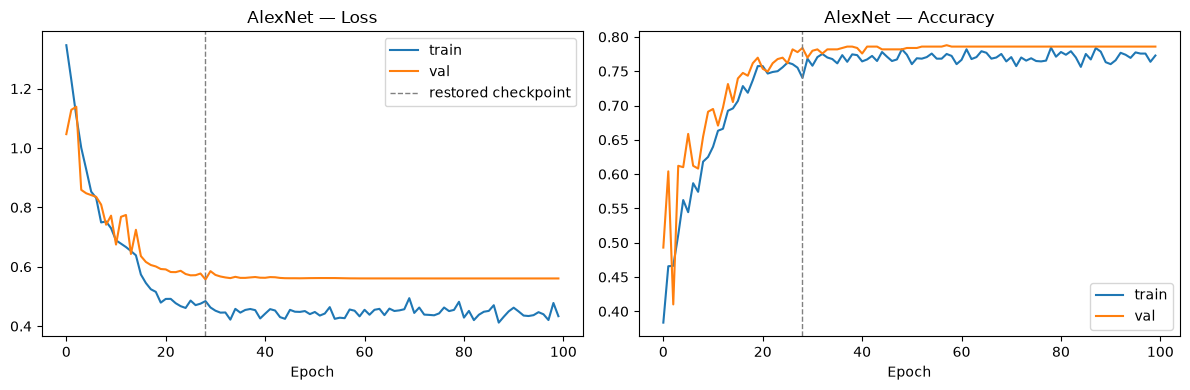

In [4]:
# No early stopping (patience=None): from random init AlexNet can sit on a
# ~ln(4) loss plateau for many epochs before it starts learning, and noisy
# val loss during that plateau made early stopping quit too soon.
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, None, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.761


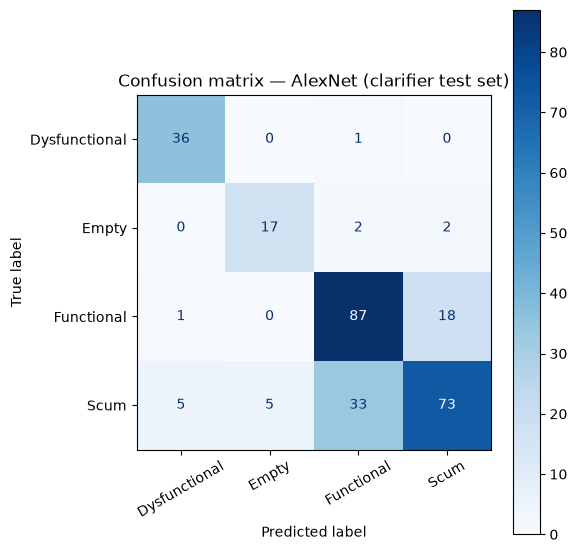

               precision    recall  f1-score   support

Dysfunctional      0.857     0.973     0.911        37
        Empty      0.773     0.810     0.791        21
   Functional      0.707     0.821     0.760       106
         Scum      0.785     0.629     0.699       116

     accuracy                          0.761       280
    macro avg      0.781     0.808     0.790       280
 weighted avg      0.764     0.761     0.757       280



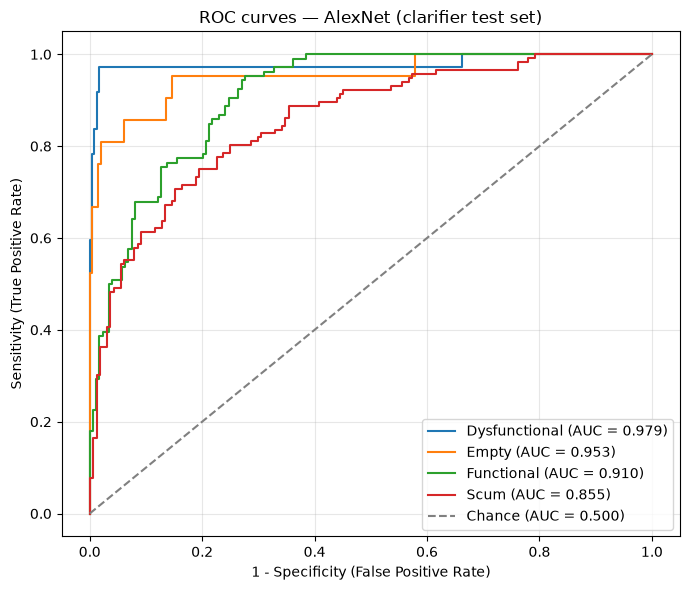

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.979
  Empty          : 0.953
  Functional     : 0.910
  Scum           : 0.855

Mean AUC (over 4/4 classes with test examples): 0.924


(np.float64(0.7607142857142857),
 {'Dysfunctional': 0.9789789789789789,
  'Empty': 0.9531163816878102,
  'Functional': 0.9103773584905661,
  'Scum': 0.8554983179142136})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/clarifier_aug/results_clarifier_alexnet_stratified.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
